## Trimming

In [1]:
# trim_memory_chat.py

import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

load_dotenv()

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

MAX_TOKENS = 120

def chat(state: MessagesState):
    trimmed_messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS,
    )

    response = model.invoke(trimmed_messages)
    return {"messages": [response]}



In [2]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_edge(START, "chat")

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "trim-demo"}}



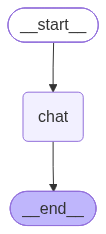

In [3]:
graph

In [4]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hello Sachin! How can I help you today?
Bot: **LangGraph & Short‑Term Memory – Quick Take**

| Concept | What it is | Why it matters |
|---------|------------|----------------|
| **LangGraph** | A framework that turns a large language model (LLM) into a *stateful* graph of conversational steps. Each node is a “tool” (e.g., ask the user, call an API, do math). Edges are transitions driven by the LLM’s output. | Lets you build complex, multi‑turn workflows where the LLM can decide what to do next. |
| **Short‑Term Memory (STM)** | A lightweight, in‑memory store that holds the *current* conversation state (e.g., user’s last question, interim results). It is *not* persisted beyond the current session. | Keeps the LLM focused on the immediate context, reduces hallucinations, and allows the graph to “remember” what just happened. |
| **How it works in LangGraph** | 1. **State** is a dictionary (e.g., `{"question": "…", "answer": "…", "step": 3}`). <br>2. Each node receives the state, ma

In [5]:
result

{'messages': [HumanMessage(content='hi my name is sachin', additional_kwargs={}, response_metadata={}, id='abeff2af-7178-4417-9f08-da3a205ae063'),
  AIMessage(content='Hello Sachin! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 77, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 28, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': None, 'queue_time': 0.211030676, 'prompt_time': 0.003812833, 'completion_time': 0.050218681, 'total_time': 0.054031514}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a12402de73', 'id': 'chatcmpl-a48278d9-1cb7-4b25-b020-3505eb1e85d1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0b94e-d5b5-71b3-bd0c-1534f7c71b47-0', tool_calls=[], invalid_tool_

## Deletion

In [6]:
# delete_memory_chat.py

import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import RemoveMessage

load_dotenv(override=True)

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def cleanup(state: MessagesState):
    messages = state["messages"]

    if len(messages) > 6:
        to_remove = messages[:4]  # delete oldest messages
        print([m.id for m in to_remove])  # print ids of messages to be removed
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}



In [7]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", cleanup)

builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")
builder.add_edge("cleanup", "__end__")

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "delete-demo"}}



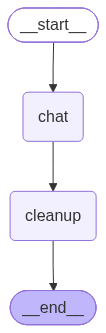

In [8]:
graph

In [9]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hello Sachin! How can I help you today?
Bot: Absolutely! LangGraph is a framework for building **graph‑based conversational AI** (and more generally, any stateful, multi‑step workflow) that sits on top of LLMs.  
Below is a “cheat‑sheet” of the key concepts, components, and design patterns you’ll encounter when you start working with it.

---

## 1. Core Concepts

| Concept | What it is | Why it matters |
|---------|------------|----------------|
| **Graph** | Directed acyclic graph (DAG) of *nodes* and *edges*. | Represents the flow of a conversation or workflow. |
| **Node** | A unit that does something: a prompt, a function call, a decision, etc. | Encapsulates a single step in the process. |
| **Edge** | A labeled transition between nodes. | Controls how the graph moves from one node to the next. |
| **State** | A dictionary (`dict[str, Any]`) that lives on the graph. | Holds all data that must survive across steps (user messages, LLM responses, metadata, etc.). |
| **Agent** 

In [10]:
result

{'messages': [HumanMessage(content='Okay, now I want to go deeper into the HITL concept. Please give me the answer for that. ', additional_kwargs={}, response_metadata={}, id='21e434f6-c455-483f-b803-94d0be638492'),
  AIMessage(content='### Human‑in‑the‑Loop (HITL) in LangGraph  \nHuman‑in‑the‑Loop (HITL) is a design pattern where a human operator (or a set of operators) is inserted into the AI workflow to **monitor, intervene, or approve** certain steps.  \nIn LangGraph, HITL is not a built‑in component per se, but the graph abstraction makes it straightforward to weave humans into any part of the conversation or workflow.\n\nBelow is a deep dive into:\n\n| Topic | What it covers |\n|-------|----------------|\n| 1. Why HITL matters | Safety, compliance, quality, and trust |\n| 2. HITL entry points in a graph | Decision nodes, verification nodes, fallback nodes |\n| 3. Implementation patterns | Prompt‑based, UI‑based, API‑based |\n| 4. State & context handling | What to expose to the h

In [ ]:
# ---- Run ----
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Sachin"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "I am learning LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Explain short term memory"}]}, config)
result = graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

print(result["messages"][-1].content)


## Summarization

In [1]:
# summary_memory_chat.py

import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, RemoveMessage

load_dotenv(override=True)

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

class ChatState(MessagesState):
    summary: str

def chat(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])
    messages.append(HumanMessage(content="Please respond to the user input. If the username is present in the entire conversation, then refer to the username if the user is going to ask explicitly about his or her name."))
    response = model.invoke(messages)
    return {"messages": [response]}

def summarize(state: ChatState):
    prompt = "Summarize the conversation so far. in a way that you can include important details in future interactions. like nameof the user, or the person you  are talking & other important deatils."

    summary_input = state["messages"] + [HumanMessage(content=prompt)]
    response = model.invoke(summary_input)

    to_delete = state["messages"][:4] 

    print([m.id for m in to_delete])  # print ids of messages to be removed

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in to_delete],
    }

def should_summarize(state: ChatState):
    return len(state["messages"]) > 6



In [2]:
builder = StateGraph(ChatState)
builder.add_node("chat", chat)
builder.add_node("summarize", summarize)

builder.add_edge(START, "chat")
builder.add_conditional_edges(
    "chat",
    should_summarize,
    {True: "summarize", False: "__end__"}
)
builder.add_edge("summarize", "__end__")

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "summary-demo"}}


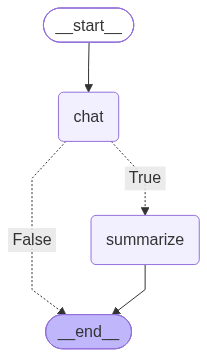

In [3]:
graph


In [14]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}],"summary":""}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hello Sachin! Nice to meet you. How can I help you today?
Bot: ### LangGraph 101 – The Building Blocks and Key Concepts

LangGraph is a framework that lets you **design, compose, and run multi‑step reasoning pipelines** (often called *agent workflows*) by wiring together small, reusable building blocks called **nodes**. Think of it as a visual “flowchart” for LLM‑driven logic, but fully programmatic, testable, and version‑controlled.

Below is a quick‑look guide covering the main aspects you’ll encounter when working with LangGraph:

| # | Aspect | What It Is | Why It Matters | Typical Use‑Case |
|---|--------|------------|----------------|------------------|
| 1 | **Graph Definition** | A directed acyclic graph (DAG) that defines the flow of data and control. | It’s the *blueprint* of your entire workflow. | Building a multi‑turn Q&A system or a data‑cleaning pipeline. |
| 2 | **Nodes** | The atomic units that perform a specific task (e.g., prompt generation, API call, data trans

In [15]:
result

{'messages': [HumanMessage(content='Tell me about human-in-the-loop in more detail. ', additional_kwargs={}, response_metadata={}, id='5ef7a3bb-2feb-4e15-97b2-8bbfb2650383'),
  AIMessage(content='## Human‑in‑the‑Loop (HITL) with LangGraph  \n*(A deep dive into design, patterns, and best‑practice code)*  \n\n---\n\n### 1. What is HITL in the context of LangGraph?\n\nHuman‑in‑the‑Loop is any workflow that **interleaves automated LLM reasoning with explicit human intervention**—whether that’s a human reviewing an answer, providing a label, or steering the next step. In LangGraph, HITL is expressed as **special “human” nodes** that pause execution, expose the current state to a user interface, and resume once the human supplies input.\n\nKey benefits:\n\n| Benefit | Why it matters |\n|---------|----------------|\n| **Safety & Compliance** | Humans can catch hallucinations, bias, or policy violations before they reach end‑users. |\n| **Quality Control** | Manual reviews ensure high‑fidelity

In [4]:


# ---- Run ----
graph.invoke({"messages": [HumanMessage(content="Hi, I'm Sachin")], "summary": ""}, config)
graph.invoke({"messages": [HumanMessage(content="I am learning LangGraph")], "summary": ""}, config)
graph.invoke({"messages": [HumanMessage(content="Explain short term memory")], "summary": ""}, config)
result = graph.invoke({"messages": [HumanMessage(content="What is my name?")], "summary": ""}, config)

print(result["messages"][-1].content)

['13cd8306-69ca-4183-a82c-95a7a6886c8b', 'lc_run--01a0b968-32d6-7082-8cf5-d63d48a11d06-0', '5af9e479-bd1f-4582-a799-fc624a97ba53', 'lc_run--01a0b968-3468-7e93-971d-f1702bf7915a-0']
Your name is Sachin.


In [5]:
result

{'messages': [HumanMessage(content='Explain short term memory', additional_kwargs={}, response_metadata={}, id='2990d69e-872a-4859-97ad-4a47b78d5fd0'),
  AIMessage(content='### Short‑Term Memory in LangGraph\n\nShort‑term memory (STM) in LangGraph is the mechanism that lets an agent *recall* recent context while it processes a new message. It’s essential for:\n\n1. **Contextual Continuity** – keeping track of what was said in the last few turns so the agent can answer follow‑ups accurately.\n2. **Stateful Interaction** – allowing the agent to remember user preferences, ongoing tasks, or partial results without storing everything permanently.\n\n#### How STM Works\n\n| Layer | What It Stores | How It’s Updated |\n|-------|----------------|------------------|\n| **Message Buffer** | The last *N* user and assistant messages (e.g., 3–5 turns). | Each new turn pushes the oldest message out of the buffer. |\n| **Fact Store** | Structured facts extracted from recent turns (e.g., “user wants p